<a href="https://colab.research.google.com/github/DariyaSavva/dsp-seminars/blob/savva_dariya_lab_6/seminars/6_savva_dariya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


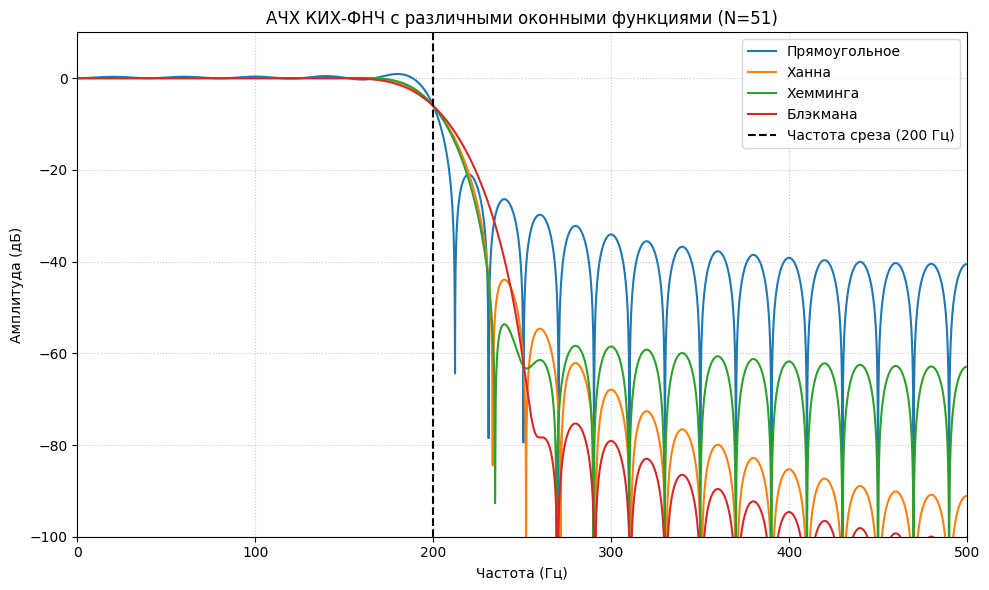

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz

# Исходные параметры
fs = 1000.0       # Частота дискретизации (Гц)
nyq = fs / 2.0    # Частота Найквиста
cutoff = 200.0    # Частота среза (Гц)
numtaps = 51      # Длина фильтра (порядок + 1)

# Словарь с окнами для удобного перебора
windows = {
    'Прямоугольное': 'boxcar',
    'Ханна': 'hann',
    'Хемминга': 'hamming',
    'Блэкмана': 'blackman'
}

plt.figure(figsize=(10, 6))

for label, win in windows.items():
    # Синтез коэффициентов КИХ-фильтра
    taps = firwin(numtaps, cutoff/nyq, window=win)

    # Вычисление частотной характеристики
    w, h = freqz(taps, worN=8000)

    # Перевод частоты в Гц, а амплитуды в децибелы
    freqs = w * fs / (2 * np.pi)
    # Используем np.maximum для избежания логарифма от нуля
    h_db = 20 * np.log10(np.maximum(np.abs(h), 1e-10))

    plt.plot(freqs, h_db, label=label)

plt.title('АЧХ КИХ-ФНЧ с различными оконными функциями (N=51)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', label='Частота среза (200 Гц)')
plt.ylim(-100, 10)
plt.xlim(0, fs/2)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

окно Блэкмана обеспечивает наилучшее подавление в полосе заграждения, а прямоугольное окно - самую крутую переходную полосу (у него самый быстрый спад АЧХ от полосы пропускания к полосе заграждения). Чем плавнее значения окна во временной области спадают к нулю на краях (как у Блэкмана и Ханна), тем лучше подавление в полосе заграждения. Плавное спадание к краям  "сужает" окно во временной области, а это приводит к расширению в частотной области. Это делает переходную полосу фильтра более пологой и широкой.

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


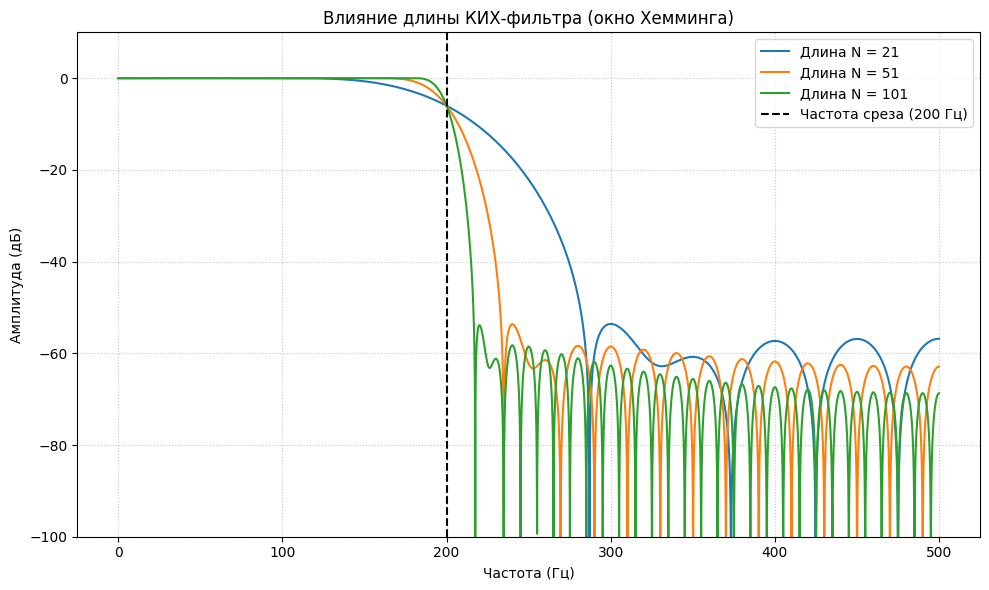

In [2]:

lengths = [21, 51, 101]

plt.figure(figsize=(10, 6))
for N in lengths:
    # Синтез фильтра с окном Хемминга для разных длин
    taps = firwin(N, cutoff/nyq, window='hamming')
    w, h = freqz(taps, worN=8000)
    freqs = w * fs / (2 * np.pi)

    h_db = 20 * np.log10(np.maximum(np.abs(h), 1e-10))
    plt.plot(freqs, h_db, label=f'Длина N = {N}')

plt.title('Влияние длины КИХ-фильтра (окно Хемминга)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', label='Частота среза (200 Гц)')
plt.ylim(-100, 10)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

Увеличение длины фильтра существенно увеличивает крутизну среза. Переходная полоса становится намного уже. Это связано с тем, что ширина главного лепестка спектра оконной функции обратно пропорциональна ее длине во времени.Увеличение длины фильтра практически не влияет на максимальный уровень боковых лепестков. Этот парметр зависит от типа выбранного окна, а не от его размера.Увеличение длины фильтра лишь ускоряет затухание дальних лепестков и увеличивает частоту пульсаций.


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


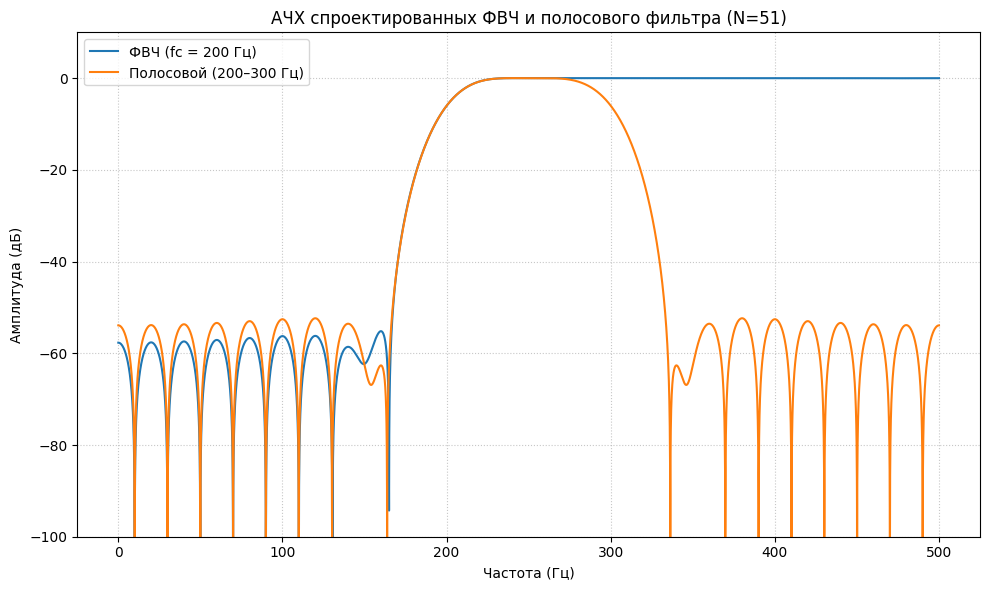

In [3]:

from scipy.signal import lfilter

numtaps = 51

# ФВЧ: для высоких частот параметр pass_zero='highpass'
taps_hpf = firwin(numtaps, 200.0/nyq, window='hamming', pass_zero='highpass')

# Полосовой фильтр: передаем список частот и pass_zero='bandpass'
taps_bpf = firwin(numtaps, [200.0/nyq, 300.0/nyq], window='hamming', pass_zero='bandpass')

# Построение АЧХ
plt.figure(figsize=(10, 6))
for taps, label in [(taps_hpf, 'ФВЧ (fc = 200 Гц)'), (taps_bpf, 'Полосовой (200–300 Гц)')]:
    w, h = freqz(taps, worN=8000)
    freqs = w * fs / (2 * np.pi)
    plt.plot(freqs, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), label=label)

plt.title('АЧХ спроектированных ФВЧ и полосового фильтра (N=51)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

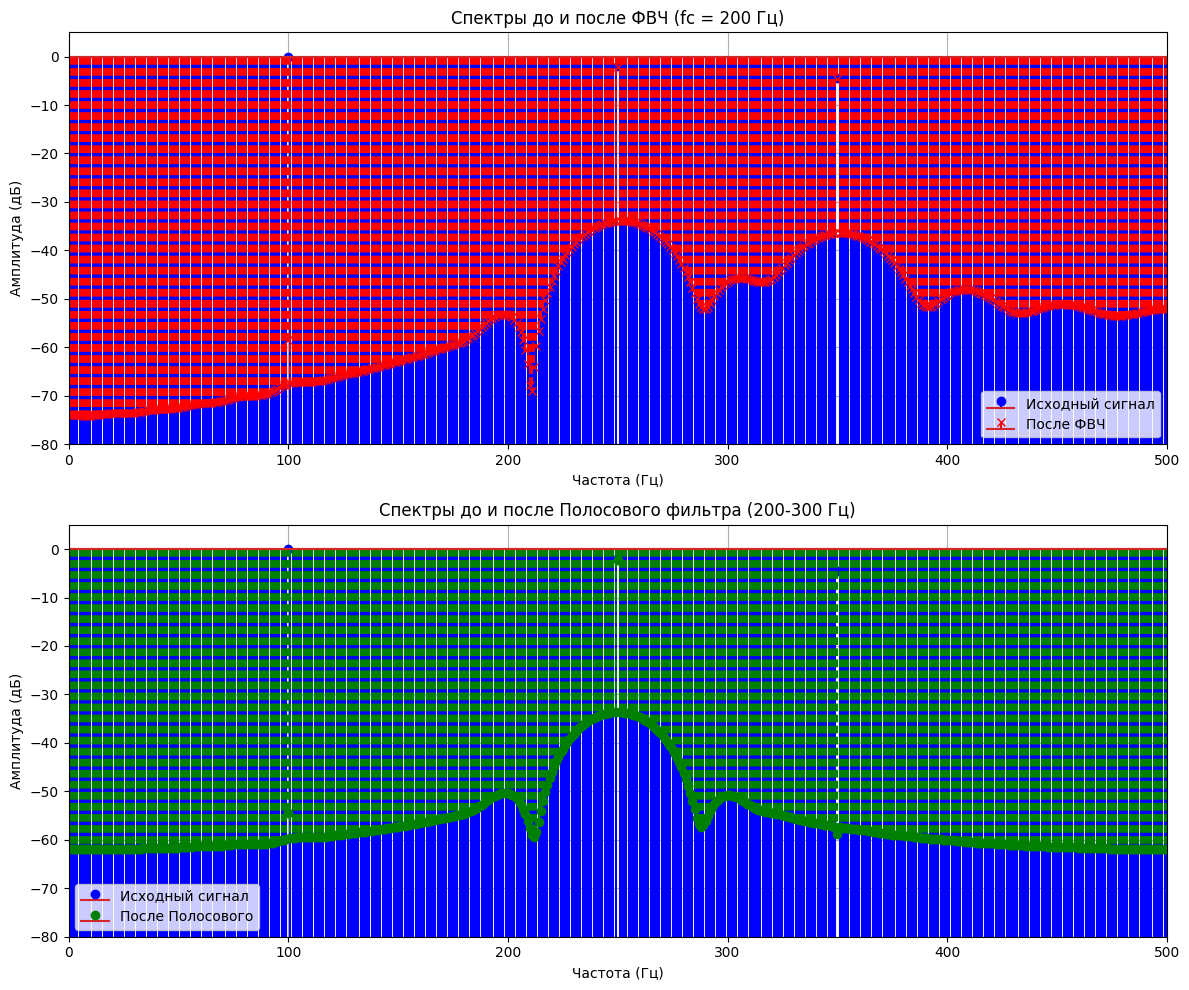

In [4]:
# Создание тестового сигнала
t = np.arange(0, 1.0, 1/fs) # 1 секунда сигнала
sig = 1.0 * np.sin(2 * np.pi * 100 * t) + 0.8 * np.sin(2 * np.pi * 250 * t) + 0.6 * np.sin(2 * np.pi * 350 * t)

# Фильтрация
filtered_hpf = lfilter(taps_hpf, 1.0, sig)
filtered_bpf = lfilter(taps_bpf, 1.0, sig)

# Вычисление спектров (БПФ)
N_fft = len(t)
freqs_fft = np.fft.rfftfreq(N_fft, 1/fs)

spec_orig = np.abs(np.fft.rfft(sig)) / N_fft * 2
spec_hpf = np.abs(np.fft.rfft(filtered_hpf)) / N_fft * 2
spec_bpf = np.abs(np.fft.rfft(filtered_bpf)) / N_fft * 2

# Построение графиков
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.stem(freqs_fft, 20 * np.log10(np.maximum(spec_orig, 1e-5)), linefmt='b-', markerfmt='bo', label='Исходный сигнал')
plt.stem(freqs_fft, 20 * np.log10(np.maximum(spec_hpf, 1e-5)), linefmt='r--', markerfmt='rx', label='После ФВЧ')
plt.title('Спектры до и после ФВЧ (fc = 200 Гц)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.xlim(0, 500)
plt.ylim(-80, 5)
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.stem(freqs_fft, 20 * np.log10(np.maximum(spec_orig, 1e-5)), linefmt='b-', markerfmt='bo', label='Исходный сигнал')
plt.stem(freqs_fft, 20 * np.log10(np.maximum(spec_bpf, 1e-5)), linefmt='g--', markerfmt='go', label='После Полосового')
plt.title('Спектры до и после Полосового фильтра (200-300 Гц)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.xlim(0, 500)
plt.ylim(-80, 5)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Объясните полученные результаты.

Исходный сигнал состоит из трех гармоник: 100 Гц (0 дБ), 250 Гц (-1.9 дБ) и 350 Гц (-4.4 дБ).
Для ФВЧ ($f_c$ = 200 Гц): Компонента 100 Гц попадает в полосу заграждения (подавляется более чем на 50 дБ и исчезает со спектра). Компоненты 250 Гц и 350 Гц лежат в полосе пропускания и остаются практически без изменений.
Для полосового фильтра (200–300 Гц): В полосу пропускания попадает только центральная гармоника (250 Гц). Крайние гармоники 100 Гц и 350 Гц находятся в соответствующих нижних и верхних полосах заграждения и успешно отфильтровываются. На спектре остается только один доминирующий пик на частоте 250 Гц.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

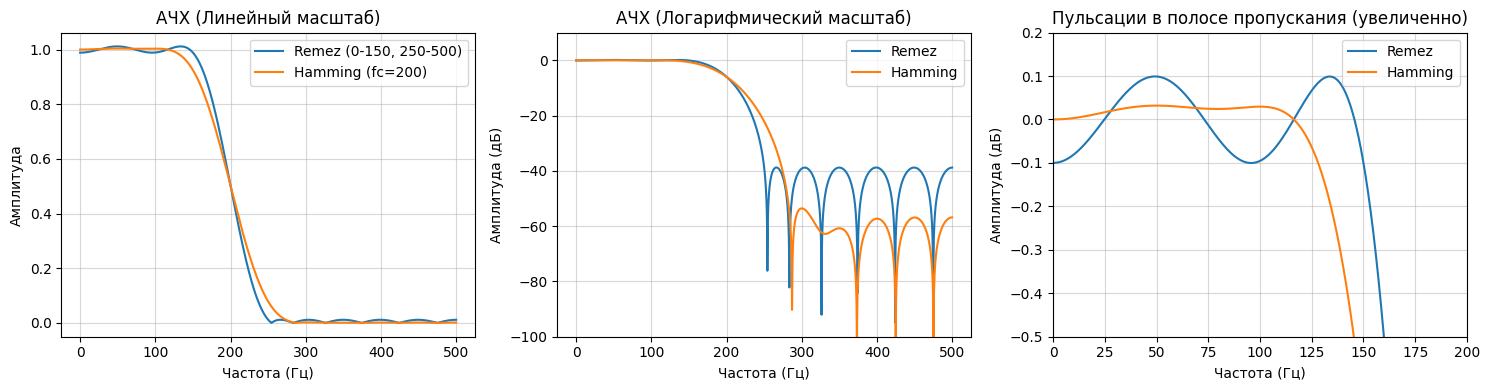

In [10]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import remez, firwin, freqz

fs = 1000.0
N = 21

# КИХ-фильтр методом Паркса-МакКлеллана (remez)
bands_remez = [0, 150, 250, 0.5 * fs]
desired = [1, 0]
taps_remez = remez(N, bands_remez, desired, fs=fs)

# КИХ-фильтр методом окон (Хемминг)
taps_hamming = firwin(N, 200, window='hamming', fs=fs)

# Вычисление АЧХ
w, h_remez = freqz(taps_remez, worN=2000, fs=fs)
_, h_hamming = freqz(taps_hamming, worN=2000, fs=fs)


plt.figure(figsize=(15, 4))

# График 1: Линейный масштаб
plt.subplot(1, 3, 1)  # ← изменено с 1,2,1 на 1,3,1
plt.plot(w, np.abs(h_remez), label='Remez (0-150, 250-500)')
plt.plot(w, np.abs(h_hamming), label='Hamming (fc=200)')
plt.title('АЧХ (Линейный масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.5)
plt.legend()

# График 2: Логарифмический масштаб
plt.subplot(1, 3, 2)  # ← изменено с 1,2,2 на 1,3,2
plt.plot(w, 20 * np.log10(np.maximum(np.abs(h_remez), 1e-10)), label='Remez')
plt.plot(w, 20 * np.log10(np.maximum(np.abs(h_hamming), 1e-10)), label='Hamming')
plt.title('АЧХ (Логарифмический масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, alpha=0.5)
plt.legend()

# График 3:
plt.subplot(1, 3, 3)
plt.plot(w, 20 * np.log10(np.maximum(np.abs(h_remez), 1e-10)), label='Remez')
plt.plot(w, 20 * np.log10(np.maximum(np.abs(h_hamming), 1e-10)), label='Hamming')
plt.title('Пульсации в полосе пропускания (увеличенно)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.xlim(0, 200)
plt.ylim(-0.5, 0.2)
plt.grid(True, alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()



**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

Фильтр Паркса–МакКлеллана (Remez) имеет заметно более крутой срез в переходной зоне по сравнению с оконным фильтром Хемминга той же длины. Пульсации в полосе пропускания для фильтра Remez составляют около 0.20 дБ, тогда как у окна Хемминга АЧХ в полосе пропускания гладкая и монотонно убывающая без выраженных "волн".

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


Подавление фильтра Хемминга: -22.13 дБ
Оптимальная ширина переходной области: 46 Гц
Верхняя граница полосы пропускания fp = 177.0 Гц
Нижняя граница полосы заграждения fs = 223.0 Гц
Подавление фильтра Remez: -22.20 дБ


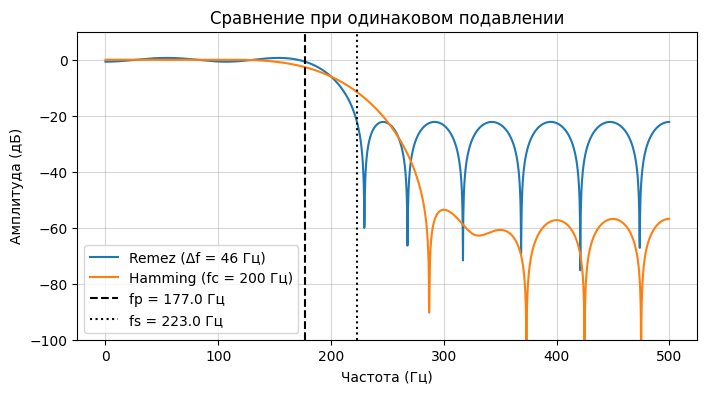

In [19]:


target_attenuation = np.max(
    20 * np.log10(np.maximum(np.abs(h_hamming[w >= 250]), 1e-10))
)

best_delta = 0
best_fp = 0
best_fstop = 0
best_stopband = 0
min_diff = float('inf')

# Ищем оптимальную ширину переходной полосы
for delta in np.arange(10, 300, 2):
    fp = 200 - delta / 2
    fstop = 200 + delta / 2

    if fp <= 0 or fstop >= 500:
        continue

    t_r = remez(N, [0, fp, fstop, 500], [1, 0], fs=fs)
    _, h = freqz(t_r, worN=2000, fs=fs)

    # Максимум в полосе заграждения
    sb_idx = w >= fstop
    max_sb = np.max(
        20 * np.log10(np.maximum(np.abs(h[sb_idx]), 1e-10))
    )

    diff = abs(max_sb - target_attenuation)

    if diff < min_diff:
        min_diff = diff
        best_delta = delta
        best_fp = fp
        best_fstop = fstop
        best_stopband = max_sb

print(f"Подавление фильтра Хемминга: {target_attenuation:.2f} дБ")
print(f"Оптимальная ширина переходной области: {best_delta} Гц")
print(f"Верхняя граница полосы пропускания fp = {best_fp:.1f} Гц")
print(f"Нижняя граница полосы заграждения fs = {best_fstop:.1f} Гц")
print(f"Подавление фильтра Remez: {best_stopband:.2f} дБ")

# Построение АЧХ с найденной шириной
taps_remez_match = remez(
    N,
    [0, best_fp, best_fstop, 500],
    [1, 0],
    fs=fs
)

_, h_remez_match = freqz(taps_remez_match, worN=2000, fs=fs)

plt.figure(figsize=(8, 4))

plt.plot(
    w,
    20 * np.log10(np.maximum(np.abs(h_remez_match), 1e-10)),
    label=f'Remez (Δf = {best_delta} Гц)'
)

plt.plot(
    w,
    20 * np.log10(np.maximum(np.abs(h_hamming), 1e-10)),
    label='Hamming (fc = 200 Гц)'
)

plt.axvline(best_fp, color='black', linestyle='--',
            label=f'fp = {best_fp:.1f} Гц')

plt.axvline(best_fstop, color='black', linestyle=':',
            label=f'fs = {best_fstop:.1f} Гц')

plt.title('Сравнение при одинаковом подавлении')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, alpha=0.5)
plt.legend()

plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

Уровень подавления в полосе заграждения у равноволнового фильтра совпал с фильтром, построенным методом окна Хемминга, при ширине переходной области
46 Гц. При этом верхняя граница полосы пропускания составила около 177 Гц, а нижняя граница полосы заграждения — около 223 Гц.
При увеличении ширины переходной области подавление в полосе заграждения возрастает, а при уменьшении — снижается.

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


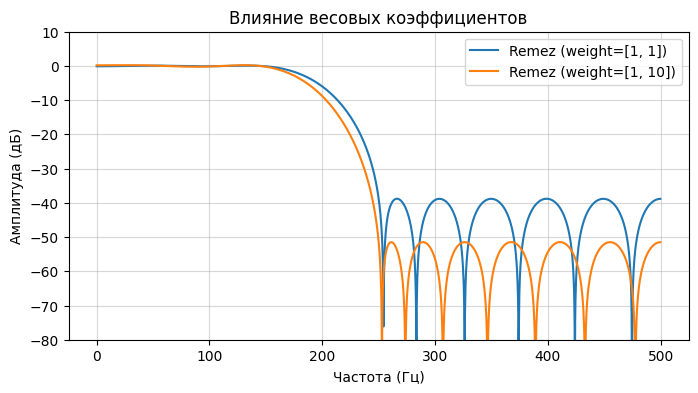


Подавление в полосе заграждения:
weight=[1,1]:  38.79 дБ
weight=[1,10]: 51.47 дБ

Подавление увеличилось с 38.79 дБ до 51.47 дБ


In [27]:



# Remez с увеличенным весом полосы заграждения
taps_remez_w = remez(N, bands_remez, desired, weight=[1, 10], fs=fs)
_, h_remez_w = freqz(taps_remez_w, worN=2000, fs=fs)

# Перевод в дБ
Hdb_normal = 20 * np.log10(np.maximum(np.abs(h_remez), 1e-10))
Hdb_weighted = 20 * np.log10(np.maximum(np.abs(h_remez_w), 1e-10))

# Максимальный уровень в полосе заграждения
max_stop_normal = np.max(Hdb_normal[w >= 250])
max_stop_weighted = np.max(Hdb_weighted[w >= 250])

# Подавление
atten_normal = -max_stop_normal
atten_weighted = -max_stop_weighted

# График
plt.figure(figsize=(8, 4))

plt.plot(
    w,
    Hdb_normal,
    label='Remez (weight=[1, 1])'
)

plt.plot(
    w,
    Hdb_weighted,
    label='Remez (weight=[1, 10])'
)

plt.title('Влияние весовых коэффициентов')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-80, 10)
plt.grid(True, alpha=0.5)
plt.legend()

plt.show()


print(f"\nПодавление в полосе заграждения:")
print(f"weight=[1,1]:  {atten_normal:.2f} дБ")
print(f"weight=[1,10]: {atten_weighted:.2f} дБ")

print(
    f"\nПодавление увеличилось "
    f"с {atten_normal:.2f} дБ "
    f"до {atten_weighted:.2f} дБ"
)

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

Подавление в полосе заграждения значительно улучшилось (уровень опустился примерно с -38.8 дБ до -51.5 дБ). Однако платой за это стало увеличение размаха равноволновых пульсаций в полосе пропускания.

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


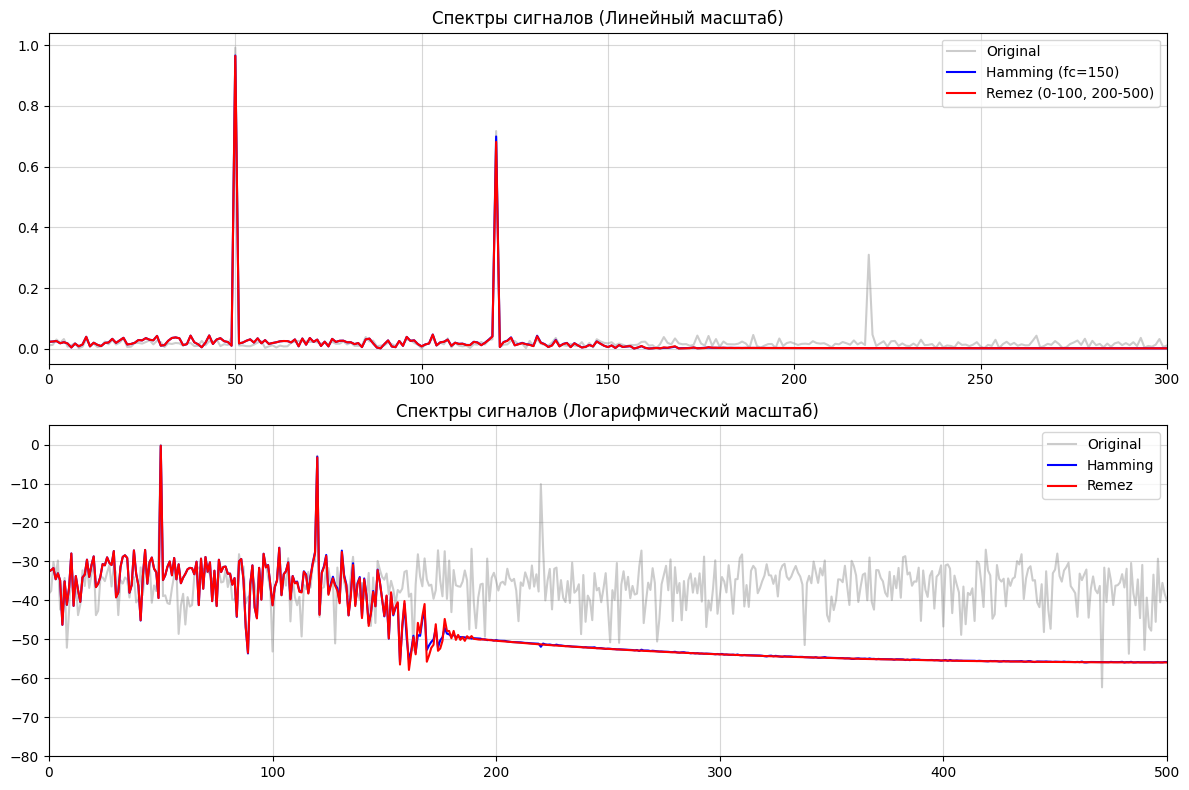

120 Гц (исходный): 0.7172
120 Гц после Hamming: 0.6994
120 Гц после Remez: 0.6815

Изменение амплитуды 120 Гц:
Hamming: -0.0179
Remez: -0.0357

220 Гц (исходный): 0.3101
220 Гц после Hamming: 0.0025
220 Гц после Remez: 0.0027


In [22]:
from scipy.signal import lfilter

np.random.seed(42)
t = np.arange(0, 1.0, 1/fs)
# Сигнал + шум
sig = 1.0 * np.sin(2 * np.pi * 50 * t) + \
      0.7 * np.sin(2 * np.pi * 120 * t) + \
      0.3 * np.sin(2 * np.pi * 220 * t) + \
      np.random.normal(0, np.sqrt(0.1), len(t))

# Фильтры N=51
taps_hamm_51 = firwin(51, 150, window='hamming', fs=fs)
taps_remez_51 = remez(51, [0, 100, 200, 500], [1, 0], fs=fs)

# Фильтрация
filt_hamm = lfilter(taps_hamm_51, 1.0, sig)
filt_remez = lfilter(taps_remez_51, 1.0, sig)

# Спектры
freqs = np.fft.rfftfreq(len(t), 1/fs)
S_orig = np.abs(np.fft.rfft(sig)) / len(t) * 2
S_hamm = np.abs(np.fft.rfft(filt_hamm)) / len(t) * 2
S_remez = np.abs(np.fft.rfft(filt_remez)) / len(t) * 2

plt.figure(figsize=(12, 8))

# Линейный масштаб
plt.subplot(2, 1, 1)
plt.plot(freqs, S_orig, label='Original', alpha=0.4, color='gray')
plt.plot(freqs, S_hamm, label='Hamming (fc=150)', color='blue')
plt.plot(freqs, S_remez, label='Remez (0-100, 200-500)', color='red')
plt.title('Спектры сигналов (Линейный масштаб)')
plt.xlim(0, 300)
plt.grid(True, alpha=0.5)
plt.legend()

# Логарифмический масштаб
plt.subplot(2, 1, 2)
plt.plot(freqs, 20 * np.log10(np.maximum(S_orig, 1e-5)), label='Original', alpha=0.4, color='gray')
plt.plot(freqs, 20 * np.log10(np.maximum(S_hamm, 1e-5)), label='Hamming', color='blue')
plt.plot(freqs, 20 * np.log10(np.maximum(S_remez, 1e-5)), label='Remez', color='red')
plt.title('Спектры сигналов (Логарифмический масштаб)')
plt.xlim(0, 500)
plt.ylim(-80, 5)
plt.grid(True, alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

def amp_at(signal_fft, freqs, f0):
    idx = np.argmin(np.abs(freqs - f0))
    return signal_fft[idx]

# Амплитуды компонентов
a120_orig = amp_at(S_orig, freqs, 120)
a120_hamm = amp_at(S_hamm, freqs, 120)
a120_remez = amp_at(S_remez, freqs, 120)

a220_orig = amp_at(S_orig, freqs, 220)
a220_hamm = amp_at(S_hamm, freqs, 220)
a220_remez = amp_at(S_remez, freqs, 220)

print(f"120 Гц (исходный): {a120_orig:.4f}")
print(f"120 Гц после Hamming: {a120_hamm:.4f}")
print(f"120 Гц после Remez: {a120_remez:.4f}")

print(f"\nИзменение амплитуды 120 Гц:")
print(f"Hamming: {a120_hamm - a120_orig:.4f}")
print(f"Remez: {a120_remez - a120_orig:.4f}")

print(f"\n220 Гц (исходный): {a220_orig:.4f}")
print(f"220 Гц после Hamming: {a220_hamm:.4f}")
print(f"220 Гц после Remez: {a220_remez:.4f}")

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Фильтр Remez лучше подавил компоненту 220 Гц и высокочастотный шум, поскольку его полоса заграждения начинается с 200 Гц и фильтр оптимизируется равноволновым методом. После фильтрации амплитуда компоненты 220 Гц уменьшилась примерно с 0.310 до 0.0027.

Компоненту 120 Гц лучше сохранил фильтр Хемминга, так как при частоте среза 150 Гц эта частота остаётся внутри полосы пропускания. У фильтра Remez частота 120 Гц находится в переходной области между 100 и 200 Гц, поэтому ослабляется сильнее.

Амплитуда компоненты 120 Гц изменилась:

для фильтра Хемминга: с 0.7172 до 0.6994 (изменение ≈ −0.0179);
для фильтра Remez: с 0.7172 до 0.6815 (изменение ≈ −0.0357).

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Ваш ответ здесь

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


In [ ]:
# Ваш код здесь

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

Ваши ответы здесь

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


In [ ]:
# Ваш код здесь

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

Ваш ответ здесь

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


In [ ]:
# Ваш код здесь

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

Ваш ответ здесь

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


Ваши ответы здесь

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

Ваши ответы здесь